In [1]:
import numpy as np
import pandas as pd
import json
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from pathlib import Path
from tqdm.notebook import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

DATASET_ROOT = Path("../../src/dataset")
POSES_ROOT   = DATASET_ROOT / "poses"
METADATA_DIR = DATASET_ROOT / "metadata"

SIGNS_TARGET = [
    "SOUFFRIR", "AIDER",    "FORT",     "MALADE",   "COEUR",
    "TETE",     "MORT",     "PLEURER",      "NON",   "FROID",
    "MANGER",    "OUI",   "TOMBER", "ACCIDENT", "MARCHER",
    "ENCEINTE", "DORMIR",  "BOIRE",     "CHAUD",  "MEDECIN"
]
SIGN_TO_IDX = {s: i for i, s in enumerate(SIGNS_TARGET)}
IDX_TO_SIGN = {i: s for i, s in enumerate(SIGNS_TARGET)}
NUM_CLASSES  = len(SIGNS_TARGET)
TARGET_T     = 32   # fixed temporal length
AUG_ROOT     = DATASET_ROOT / "augmented_tcn"

print(f"Classes: {NUM_CLASSES}, Target T: {TARGET_T}")


Using device: cuda
Classes: 20, Target T: 32


In [2]:
instances = pd.read_csv(DATASET_ROOT / "instances.csv")
face_files = list((POSES_ROOT / "face").glob("*.npy"))
available  = {f.stem for f in face_files}

df = instances[instances["id"].isin(available)].copy()
df["label"] = df["sign"].map(SIGN_TO_IDX)
df = df[df["label"].notna()].copy()
df["label"] = df["label"].astype(int)

# Remove T=0 instances
lengths = {f.stem: np.load(f).shape[0] for f in face_files if f.stem in set(df["id"])}
df["T"] = df["id"].map(lengths)
df = df[df["T"] > 0].reset_index(drop=True)

# Load splits
with open(METADATA_DIR / "splits" / "train.json") as f:
    train_ids = set(json.load(f))
with open(METADATA_DIR / "splits" / "test.json") as f:
    test_ids = set(json.load(f))

df_train = df[df["id"].isin(train_ids)].reset_index(drop=True)
df_test  = df[df["id"].isin(test_ids)].reset_index(drop=True)

print(f"Train: {len(df_train)} | Test: {len(df_test)}")
print("\nClass distribution (train):")
print(df_train["sign"].value_counts().to_string())

Train: 2856 | Test: 2225

Class distribution (train):
sign
OUI         1291
NON          599
FORT         279
AIDER        116
MANGER       115
CHAUD         55
TOMBER        51
DORMIR        51
BOIRE         49
MARCHER       40
PLEURER       30
FROID         25
ENCEINTE      25
MORT          24
TETE          22
SOUFFRIR      21
COEUR         21
MALADE        17
ACCIDENT      16
MEDECIN        9


In [3]:
def resample_sequence(arr: np.ndarray, target_T: int) -> np.ndarray:
    """Resample (T, K, 3) array to target_T frames via linear interpolation."""
    T = arr.shape[0]
    if T == target_T:
        return arr
    idx = np.linspace(0, T - 1, target_T)
    lo  = np.floor(idx).astype(int).clip(0, T - 1)
    hi  = np.ceil(idx).astype(int).clip(0, T - 1)
    a   = (idx - lo)[:, None, None]
    return ((1 - a) * arr[lo] + a * arr[hi]).astype(np.float32)


def load_coords(instance_id: str, target_T: int = TARGET_T) -> np.ndarray:
    """
    Load body + left_hand + right_hand coordinates for one instance.

    Returns float32 array of shape (225, T):
      - 225 = (33 body + 21 left_hand + 21 right_hand) * 3 coords
      - T   = target_T frames
    Channel-first format for Conv1d input.
    """
    body  = np.load(POSES_ROOT / "pose"       / f"{instance_id}.npy").astype(np.float32)
    lhand = np.load(POSES_ROOT / "left_hand"  / f"{instance_id}.npy").astype(np.float32)
    rhand = np.load(POSES_ROOT / "right_hand" / f"{instance_id}.npy").astype(np.float32)

    body  = resample_sequence(body,  target_T)   # (T, 33, 3)
    lhand = resample_sequence(lhand, target_T)   # (T, 21, 3)
    rhand = resample_sequence(rhand, target_T)   # (T, 21, 3)

    # Flatten keypoints: (T, K, 3) -> (T, K*3) then transpose to (K*3, T)
    body_flat  = body.reshape(target_T, -1)    # (T, 99)
    lhand_flat = lhand.reshape(target_T, -1)   # (T, 63)
    rhand_flat = rhand.reshape(target_T, -1)   # (T, 63)

    coords = np.concatenate([body_flat, lhand_flat, rhand_flat], axis=1)  # (T, 225)
    return coords.T  # (225, T) channel-first for Conv1d


# Sanity check
sample_id = df_train["id"].iloc[0]
x = load_coords(sample_id)
assert x.shape == (225, TARGET_T), f"Expected (225, {TARGET_T}), got {x.shape}"
print(f"load_coords OK: shape={x.shape}, range=[{x.min():.3f}, {x.max():.3f}]")

load_coords OK: shape=(225, 32), range=[-1.158, 1.267]


In [5]:
class CoordDataset(Dataset):
    """
    Dataset for TCN skeleton coordinates.

    - npy_root=None : loads from POSES_ROOT via load_coords (used for test set)
    - npy_root=Path : loads pre-computed (225, T) arrays from augmented_tcn/npy/ (used for train)
    """

    def __init__(self, df: pd.DataFrame, npy_root=None, target_T: int = TARGET_T):
        self.df       = df.reset_index(drop=True)
        self.npy_root = npy_root
        self.target_T = target_T

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        if self.npy_root is not None:
            coords = np.load(self.npy_root / f"{row['id']}.npy").astype(np.float32)
        else:
            coords = load_coords(row["id"], self.target_T)
        return torch.from_numpy(coords), torch.tensor(row["label"], dtype=torch.long)


# Load augmented train metadata
df_aug = pd.read_csv(AUG_ROOT / "metadata.csv")
print(f"Augmented train: {len(df_aug)} instances")
print(df_aug.groupby("sign").size().reindex(SIGNS_TARGET).to_string())

train_dataset = CoordDataset(df_aug,  npy_root=AUG_ROOT / "npy")
test_dataset  = CoordDataset(df_test, npy_root=None)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
assert xb.shape == (16, 225, TARGET_T), f"Expected (16, 225, {TARGET_T}), got {xb.shape}"
print(f"
Batch: X={xb.shape}, y={yb.shape}, dtype={xb.dtype}")


Batch: X=torch.Size([16, 225, 32]), y=torch.Size([16]), dtype=torch.float32


In [6]:
class TemporalBlock(nn.Module):
    """
    One residual TCN block:
      - Two dilated causal Conv1d layers with same padding
      - BatchNorm + ReLU + Dropout after each conv
      - Residual connection (with 1x1 conv if channel dims differ)
    """

    def __init__(self, in_channels: int, out_channels: int,
                 kernel_size: int = 3, dilation: int = 1,
                 dropout: float = 0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2  # same padding

        self.conv1 = nn.Conv1d(in_channels,  out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.bn1   = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.bn2   = nn.BatchNorm1d(out_channels)

        self.relu    = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)

        self.downsample = (
            nn.Conv1d(in_channels, out_channels, 1)
            if in_channels != out_channels else None
        )

    def forward(self, x):
        residual = x if self.downsample is None else self.downsample(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.dropout(out)
        return self.relu(out + residual)


class TCN(nn.Module):
    """
    Temporal Convolutional Network for skeleton-based sign recognition.

    Input:  (batch, 225, T=32)   â€” raw coordinate features, channel-first
    Output: (batch, num_classes)

    Architecture:
      Linear projection 225 -> 128
      4 TemporalBlocks with exponentially growing dilation (1, 2, 4, 8)
      Global average pooling over time
      Dropout + Linear classifier
    """

    def __init__(self, in_channels: int = 225, num_classes: int = 20,
                 hidden: int = 128, dropout: float = 0.3):
        super().__init__()

        self.input_proj = nn.Conv1d(in_channels, hidden, kernel_size=1)

        self.blocks = nn.Sequential(
            TemporalBlock(hidden, hidden, kernel_size=3, dilation=1,  dropout=dropout),
            TemporalBlock(hidden, hidden, kernel_size=3, dilation=2,  dropout=dropout),
            TemporalBlock(hidden, hidden, kernel_size=3, dilation=4,  dropout=dropout),
            TemporalBlock(hidden, hidden, kernel_size=3, dilation=8,  dropout=dropout),
        )

        self.pool      = nn.AdaptiveAvgPool1d(1)
        self.dropout   = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden, num_classes)

    def forward(self, x):
        # x: (B, 225, T)
        x = self.input_proj(x)    # (B, 128, T)
        x = self.blocks(x)        # (B, 128, T)
        x = self.pool(x).squeeze(-1)  # (B, 128)
        x = self.dropout(x)
        return self.classifier(x) # (B, num_classes)


# Verify
model = TCN(in_channels=225, num_classes=NUM_CLASSES, hidden=128, dropout=0.3).to(DEVICE)
dummy = torch.randn(4, 225, TARGET_T).to(DEVICE)
out   = model(dummy)
assert out.shape == (4, NUM_CLASSES), f"Expected (4,{NUM_CLASSES}), got {out.shape}"

total_params = sum(p.numel() for p in model.parameters())
print(f"TCN output shape: {out.shape}  [OK]")
print(f"Total parameters: {total_params:,}  (vs I3D ~12M)")

TCN output shape: torch.Size([4, 20])  [OK]
Total parameters: 427,796  (vs I3D ~12M)


In [7]:
os.makedirs("../../src/models", exist_ok=True)

# Inverse-frequency class weights â€” bincount guarantees all 20 classes present
counts     = np.bincount(df_aug["label"].values, minlength=NUM_CLASSES).astype(np.float32)
ce_weights = torch.tensor(1.0 / np.maximum(counts, 1.0), dtype=torch.float32).to(DEVICE)
ce_weights /= ce_weights.sum()

criterion = nn.CrossEntropyLoss(weight=ce_weights)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80, eta_min=1e-5)

print("Loss, optimizer, scheduler defined.")
print(f"  LR: {optimizer.param_groups[0]['lr']:.1e}")
print(f"  Weight decay: {optimizer.param_groups[0]['weight_decay']:.1e}")

Loss, optimizer, scheduler defined.
  LR: 3.0e-04
  Weight decay: 1.0e-03


In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)
            preds       = logits.argmax(1)
            correct    += (preds == y_batch).sum().item()
            total      += len(y_batch)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    avg_loss = total_loss / total
    accuracy = correct / total
    f1       = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, accuracy, f1, np.array(all_preds), np.array(all_labels)


print("train_one_epoch and evaluate defined.")

train_one_epoch and evaluate defined.


In [9]:
NUM_EPOCHS        = 80
PATIENCE          = 15
best_val_acc      = 0.0
epochs_no_improve = 0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, test_loader, criterion, DEVICE)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:03d}/{NUM_EPOCHS} | "
            f"train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
            f"val loss={val_loss:.4f} acc={val_acc:.3f} f1={val_f1:.3f} | "
            f"lr={lr:.1e}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), "../../src/models/best_tcn.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch 001/80 | train loss=2.5075 acc=0.163 | val loss=4.7008 acc=0.013 f1=0.016 | lr=3.0e-04
Epoch 002/80 | train loss=1.8380 acc=0.282 | val loss=4.5958 acc=0.027 f1=0.039 | lr=3.0e-04
Epoch 003/80 | train loss=1.6587 acc=0.324 | val loss=4.5821 acc=0.026 f1=0.052 | lr=3.0e-04
Epoch 004/80 | train loss=1.3896 acc=0.389 | val loss=10.9953 acc=0.014 f1=0.031 | lr=3.0e-04
Epoch 005/80 | train loss=1.2393 acc=0.417 | val loss=4.7125 acc=0.031 f1=0.058 | lr=3.0e-04
Epoch 006/80 | train loss=1.1766 acc=0.435 | val loss=4.5783 acc=0.034 f1=0.089 | lr=3.0e-04
Epoch 007/80 | train loss=1.0560 acc=0.463 | val loss=4.1699 acc=0.044 f1=0.091 | lr=2.9e-04
Epoch 008/80 | train loss=0.9935 acc=0.484 | val loss=4.5795 acc=0.048 f1=0.077 | lr=2.9e-04
Epoch 009/80 | train loss=0.9405 acc=0.506 | val loss=4.7406 acc=0.047 f1=0.064 | lr=2.9e-04
Epoch 010/80 | train loss=0.8400 acc=0.537 | val loss=4.2787 acc=0.045 f1=0.101 | lr=2.9e-04
Epoch 011/80 | train loss=0.8868 acc=0.516 | val loss=4.4134 acc=0.05

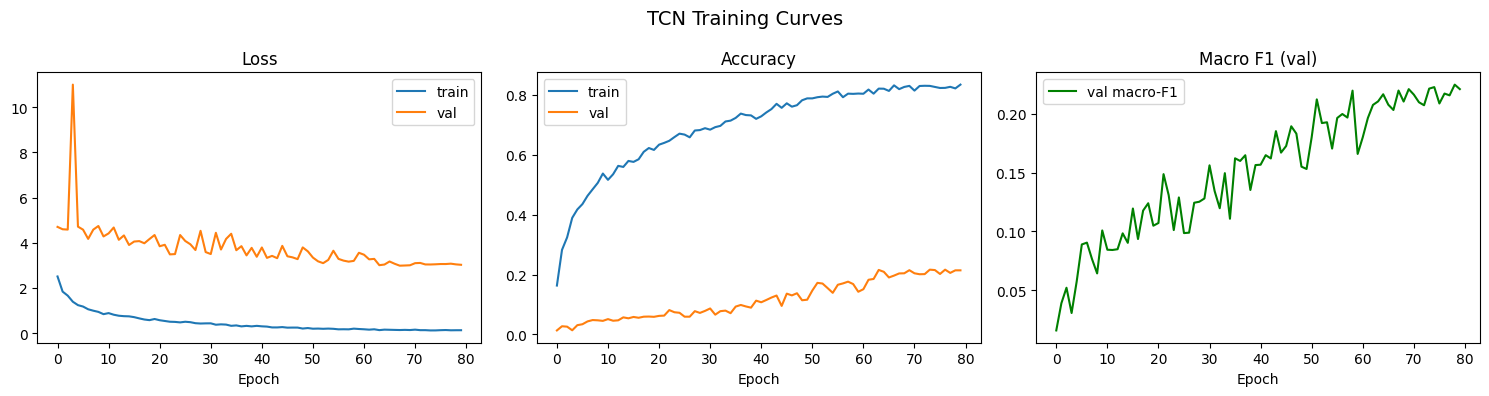

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"],   label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"],   label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(history["val_f1"], label="val macro-F1", color="green")
axes[2].set_title("Macro F1 (val)")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.suptitle("TCN Training Curves", fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# Load best checkpoint
model.load_state_dict(torch.load("../../src/models/best_tcn.pth", map_location=DEVICE))

_, test_acc, test_f1, preds, labels = evaluate(model, test_loader, criterion, DEVICE)

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Macro-F1 : {test_f1:.4f}")
print()
print(classification_report(labels, preds, target_names=SIGNS_TARGET, zero_division=0))

Test Accuracy : 0.2162
Test Macro-F1 : 0.2213

              precision    recall  f1-score   support

    SOUFFRIR       0.18      0.76      0.29        17
       AIDER       0.62      0.53      0.57        53
        FORT       0.59      0.44      0.51       205
      MALADE       0.14      0.89      0.25         9
       COEUR       0.09      0.56      0.15         9
        TETE       0.30      0.43      0.35        14
        MORT       0.03      0.25      0.05        12
     PLEURER       0.16      0.33      0.22        21
         NON       0.61      0.24      0.34       583
       FROID       0.04      0.18      0.06        22
      MANGER       0.19      0.34      0.24        92
         OUI       0.82      0.06      0.11      1013
      TOMBER       0.06      0.22      0.09        18
    ACCIDENT       0.00      0.00      0.00         4
     MARCHER       0.13      0.37      0.19        38
    ENCEINTE       0.17      0.71      0.27        14
      DORMIR       0.19      0.84 

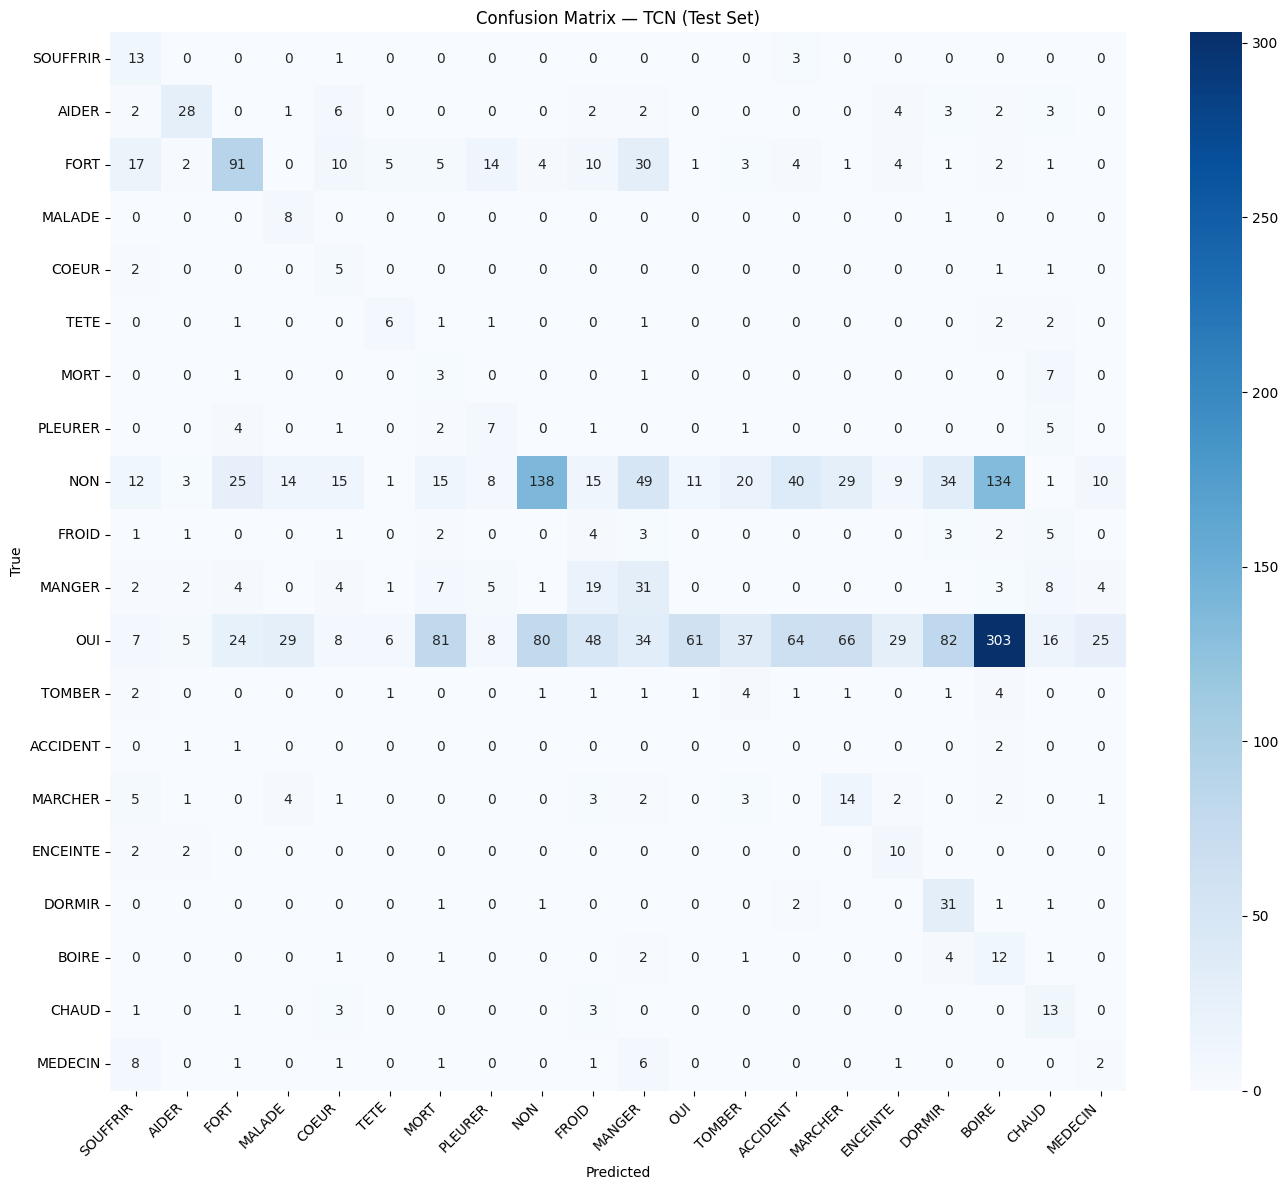

In [12]:
cm = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=SIGNS_TARGET,
    yticklabels=SIGNS_TARGET,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix â€” TCN (Test Set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [13]:
def save_tcn(model: nn.Module, path: str, metadata: dict = None):
    """Save TCN weights and optional metadata."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    payload = {"state_dict": model.state_dict()}
    if metadata:
        payload["metadata"] = metadata
    torch.save(payload, path)
    print(f"Model saved to {path}")


def predict_sign_tcn(instance_id: str, model: nn.Module, device) -> tuple:
    """
    Predict the sign for a single instance from its pose files.
    Returns: (predicted_sign_name, confidence_score)
    """
    model.eval()
    coords = load_coords(instance_id, TARGET_T)  # (225, T)
    x = torch.from_numpy(coords).unsqueeze(0).to(device)  # (1, 225, T)
    with torch.no_grad():
        logits = model(x)
        probs  = torch.softmax(logits, dim=1)
        idx    = probs.argmax(1).item()
        conf   = probs[0, idx].item()
    return IDX_TO_SIGN[idx], conf


# Save with metadata
save_tcn(model, "../../src/models/tcn_medisign_final.pth", metadata={
    "test_accuracy": round(float(test_acc), 4),
    "test_macro_f1": round(float(test_f1), 4),
    "num_classes":   NUM_CLASSES,
    "signs":         SIGNS_TARGET,
    "input_shape":   [225, TARGET_T],
    "architecture":  "TCN (4 TemporalBlocks, hidden=128)",
})

# Inference examples
print("\nInference examples:")
for sign in ["SOUFFRIR", "AIDER", "FORT", "COEUR", "TETE"]:
    row  = df[df["sign"] == sign].iloc[0]
    pred, conf = predict_sign_tcn(row["id"], model, DEVICE)
    status = "OK" if pred == sign else "X"
    print(f"  [{status}] True: {sign:<12} Pred: {pred:<12} Conf: {conf:.3f}")

Model saved to ../../src/models/tcn_medisign_final.pth

Inference examples:
  [OK] True: SOUFFRIR     Pred: SOUFFRIR     Conf: 0.262
  [OK] True: AIDER        Pred: AIDER        Conf: 0.937
  [X] True: FORT         Pred: MANGER       Conf: 0.436
  [OK] True: COEUR        Pred: COEUR        Conf: 0.999
  [X] True: TETE         Pred: BOIRE        Conf: 0.981
